# Evaluation Metrics

In [1]:
from __future__ import annotations

import os
import random
from datetime import datetime
from typing import TYPE_CHECKING

import matplotlib.pyplot as plt
import numpy as np
import pandapower as pp
import pandapower.plotting as plot
import pandas as pd
import simbench
from gymnasium import spaces
from matplotlib.dates import DateFormatter
from pandapower.networks import case14, case30, case118, case300, case2869pegase
from pandapower.powerflow import LoadflowNotConverged

from pandapower_env.action_space.action_space import (
    add_actions_substation_line_switching,
    create_actions_df,
    create_unitary_line_actions_and_donothing,
    create_unitary_substation_action,
    enforce_rules,
)
from pandapower_env.action_space.substation_action_rules import (
    passes_fully_connected_grid_rule,
    passes_islanded_elements_rule,
    passes_n_elements_rule,
    passes_two_bus_symmetry_rule,
)
from pandapower_env.agents.benchmark_agents import (
    DoNothingAgent,
    GreedyAgent,
    NminusOneGreedyAgent,
    RandomAgent,
)
from pandapower_env.environments.simulation_env import (
    PPTopoGym,
)
from pandapower_env.observation_space.pp_to_observation import (
    clipped_line_loading_observation_space,
    line_loading_mean,
    line_overloading_percentage,
    line_overloading_sum,
    line_power_losses_sum,
    nminus1_bus_overloading_percentage,
    nminus1_line_loading_max,
    nminus1_line_loading_mean,
    nminus1_line_overloading_percentage,
    nminus1_line_overloading_sum,
    open_busbar_coupler_percentage,
)
from pandapower_env.substation.create_double_busbar_substation import (
    can_convert_to_n_busbar_substation,
    create_all_double_busbar_substations,
    n_assignable_elements_in_bus,
)
from pandapower_env.substation.plot_double_busbar_substation import (
    separate_substation_buses_visually,
)
from pandapower_env.toolbox.plotting_helpers import (
    calculate_externals_locations,
    label_lines,
    label_substations,
    plot_all_peripherals,
)
from pandapower_env.toolbox.utils import (
    run_nminus1_powerflow,
)
from pandapower_env.toolbox.utils_profiles import (
    add_random_profiles,
    get_profile_names,
    get_scenario_profiles,
    setup_profiles,
)

from pandapower_env.toolbox.utils_scaling import (
    find_max_timestep,
    find_scaling_binarysearch,
)

In [2]:
# imports to show-case usage, actually only EvaluateMetrics is needed
from pandapower_env.metrics.evaluation_metrics import AllMetrics
from pandapower_env.metrics.metric_utils import EvaluateMetrics, MetricContainer

print("All functions available for evaluation:")
allmetrics = MetricContainer()


def all_subclasses(cls):
    return set(cls.__subclasses__()).union(
        [s for c in cls.__subclasses__() for s in all_subclasses(c)],
    )


def method_from_class(cls):
    return [func for func in dir(cls) if not func.startswith("__")]


all_subclasses_list = all_subclasses(allmetrics.__class__)
method_dict_name_class = {}
for subclass in all_subclasses_list:
    for func in method_from_class(subclass):
        method_dict_name_class[func] = subclass

for method, class_ in method_dict_name_class.items():
    func = getattr(class_, method)
    print(func.get_name())

All functions available for evaluation:
action_entropy
average_reward
grid_max_timestep_overload
line_max_timestep_overload
max_line_loading_mean_nminus0
max_line_loading_nminus0
max_line_loading_nminus1
max_line_loading_var_nminus0
max_lines_overloaded_nminus0
open_busbar_couplers
open_busbar_couplers_window_32ts
sum_line_loading_nminus0


In [3]:
# Imports
from __future__ import annotations

import copy

if TYPE_CHECKING:
    import pandas as pd

In [4]:
net = case30()
net.profiles = simbench.get_all_simbench_profiles(0)


def get_profile_names(df_profile: pd.DataFrame) -> tuple:
    """Quick function to get the names of each of the profiles offered by Simbench."""
    return (
        df_profile.columns[1:]
        .to_series()
        .apply(lambda x: x.replace("_pload", "").replace("_qload", ""))
        .unique()
    )


# Randomly select some profiles to load.
rng = np.random.default_rng(seed=12345)
net.load["profile"] = rng.choice(
    get_profile_names(net.profiles["load"]),
    len(net.load),
)
net.gen["profile"] = rng.choice(
    get_profile_names(net.profiles["powerplants"]),
    len(net.gen),
)
net.sgen["profile"] = rng.choice(
    get_profile_names(net.profiles["renewables"]),
    len(net.sgen),
)

# Make sure loads, generators each have unique names
net.gen["name"] = net.gen.index.to_series().apply(lambda x: f"Generator {x}")
net.sgen["name"] = net.sgen.index.to_series().apply(
    lambda x: f"Static Generator {x}",
)
net.load["name"] = net.load.index.to_series().apply(lambda x: f"Load {x}")

create_all_double_busbar_substations(net)
actions = add_actions_substation_line_switching(net)
env_config = {
    "net": net,
    "n_episodes": 1,
    "episode_length": 6,
    "action_space": actions,
    "nminus1": False,
}

env_config_copy = copy.deepcopy(env_config)

simenv = PPTopoGym(env_config)
loads_begin = copy.deepcopy(net.load["profile"].unique().tolist())
gens_begin = copy.deepcopy(net.gen["profile"].unique().tolist())
sgens_begin = copy.deepcopy(net.sgen["profile"].unique().tolist())

In [5]:
# Load and run Agent and store the taken actions
# import agents

In [6]:
# Evaluate the agent
taken_actions = {}
actions_gym = spaces.Discrete(len(actions))
agents = [
    DoNothingAgent(actions_gym),
    # GreedyAgent(actions_gym, env_config),
]
agent = agents[0]
simenv = PPTopoGym(env_config)
id_start = 0
timesteps = 6
id_end = id_start + timesteps
step_size = 1
# run agents
max_loading_percent_all_agents = []
max_nminus1_all_agents = []
print(f"Start running agent {agent.__class__.__name__}")
max_loading_percent = []
max_nminus1_loading_percent = []
# simenv.reset()
# pp.runpp(simenv.net)
for id_, time in enumerate(range(id_start, id_end - 3, step_size)):
    obs = simenv.create_observation()
    terminated = False
    try:
        action = agent.act(observation=obs)
    except TypeError:
        action = agent.act()
    obs_step, reward, terminated, truncated, info = simenv.step(action)
    nminus0 = np.max(obs_step["line_loadings"])
    # create nminus1 observation
    try:
        pp.runpp(simenv.net)
        run_nminus1_powerflow(simenv.net)
        obs_step["nminus1"] = np.max(nminus1_line_loading_max(simenv.net))
    except LoadflowNotConverged:
        obs_step["nminus1"] = float("inf")
    nminus1 = np.max(obs_step["nminus1"])
    max_loading_percent.append(nminus0)
    max_nminus1_loading_percent.append(nminus1)
    print(f"Step {id_+1}: time {time}, {action} -> {nminus0}, N-1: {nminus1}")
    if terminated:
        break
print(f"Episode finished after {id_+1} timesteps.")
max_nminus1_all_agents.append(max_nminus1_loading_percent)
max_loading_percent_all_agents.append(max_loading_percent)
taken_actions[agent.__class__.__name__] = simenv.log_actions
print(
    f"Finished running agent {agent.__class__.__name__} with the actions {taken_actions[agent.__class__.__name__]}",
)

Start running agent DoNothingAgent
Step 1: time 0, 0 -> 29.137014389038086, N-1: 37.661438945372986
Step 2: time 1, 0 -> 34.046871185302734, N-1: 44.181424802521555
Step 3: time 2, 0 -> 23.712018966674805, N-1: 32.26757572987381
Episode finished after 3 timesteps.
Finished running agent DoNothingAgent with the actions [0 0 0 None None None]


In [7]:
import copy

actions = simenv.log_actions  # for try-out
eval = EvaluateMetrics(env_config_copy, actions)
eval.run()
print(eval)

FloatMetric(name=action_entropy)
action_entropy: value=-0.0, cache={'actions': [0, 0, 0]}
FloatMetric(name=average_reward)
average_reward: value=171.0346991060486, cache={'rewards': [np.float64(170.86298566617035), np.float64(165.95312968181565), np.float64(176.28798197015985)]}
FloatMetric(name=grid_max_timestep_overload)
grid_max_timestep_overload: value=0.0, cache={'grid_overloaded': [np.False_, np.False_, np.False_], 'longest_grid_overload': [0, 0, 0]}
FloatMetric(name=line_max_timestep_overload)
line_max_timestep_overload: value=0.0, cache={'highest_timestep_one_line_overloaded': [0, 0, 0], '_lines_overloaded': [[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False], [False, False, False, False, False, False, False, False, False, False, False, False, F

In [8]:
print(eval.gather_results())

{'action_entropy': {'value': -0.0, 'cache': {'actions': [0, 0, 0]}}, 'average_reward': {'value': np.float64(171.0346991060486), 'cache': {'rewards': [np.float64(170.86298566617035), np.float64(165.95312968181565), np.float64(176.28798197015985)]}}, 'grid_max_timestep_overload': {'value': 0.0, 'cache': {'grid_overloaded': [np.False_, np.False_, np.False_], 'longest_grid_overload': [0, 0, 0]}}, 'line_max_timestep_overload': {'value': 0.0, 'cache': {'highest_timestep_one_line_overloaded': [0, 0, 0], '_lines_overloaded': [[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False], [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, Fals

# Run more metrics and plot them

Evaluations for:
DoNothingAgent: 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
GreedyAgent: 47, 164, 18, 186, 27, 151, 159, 16, 205, 106, 182, 1, 18, 12, 156, 125, 14, 197, 2, 124, 180, 201, 4, 223
NminusOneGreedyAgent: 49, 198, 223, 207, 156, 106, 269, 153, 206, 257, 155, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [9]:
donothing_actions = [
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
] * 4

greedy_actions = [
    47,
    164,
    18,
    186,
    27,
    151,
    159,
    16,
    205,
    106,
    182,
    1,
    18,
    12,
    156,
    125,
    14,
    197,
    2,
    124,
    180,
    201,
    4,
    223,
]
nminus1Greedy_actions = [
    49,
    198,
    223,
    207,
    156,
    106,
    269,
    153,
    206,
    257,
    155,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
]

# Based on data.example_configs

In [10]:
taken_actions = dict()
actions = [188, 46, 91, 8, 172, 0, 50, 91, 113, 88, 163, 114, 51, 91, 262, 87, 94, 2, 93, 104, 93, 65, 155, 343, 344, 234, 191, 242, 85, 6, 89, 0, 66, 45, 0, 89, 87, 92, 10, 93, 75, 253, 21, 178, 264, 39, 72, 108, 157, 75, 108, 72, 297, 166, 80, 100, 78, 72, 158, 236, 100, 76, 98, 210, 248, 114, 221, 215, 249, 68, 298, 260, 20, 79, 2, 12, 28, 166, 49, 105, 171, 163, 150, 100, 79, 164, 329, 222, 0, 113, 161, 72, 155, 191, 245, 75]
taken_actions["GreedyNminus0"] = actions

In [11]:
from pandapower_env.data.example_configs import config_case30

env_config = config_case30()
print("config ready")
env_config_copy = copy.deepcopy(env_config)
eval = EvaluateMetrics(env_config_copy, actions)
eval.run()
results = eval.gather_results()
print(results)
print(next(iter(results["max_line_loading_nminus0"]["cache"].values())))


/Users/dkoehler/Desktop/Python Projects/Arbeit/PPTopo/pandapower_env/toolbox/utils_profiles.py:154: RuntimeWarning: divide by zero encountered in matmul
  profiles["load_p"].to_numpy() @ np.diag(net.load["scenario_scaling"]),
/Users/dkoehler/Desktop/Python Projects/Arbeit/PPTopo/pandapower_env/toolbox/utils_profiles.py:154: RuntimeWarning: overflow encountered in matmul
  profiles["load_p"].to_numpy() @ np.diag(net.load["scenario_scaling"]),
/Users/dkoehler/Desktop/Python Projects/Arbeit/PPTopo/pandapower_env/toolbox/utils_profiles.py:154: RuntimeWarning: invalid value encountered in matmul
  profiles["load_p"].to_numpy() @ np.diag(net.load["scenario_scaling"]),
/Users/dkoehler/Desktop/Python Projects/Arbeit/PPTopo/pandapower_env/toolbox/utils_profiles.py:164: RuntimeWarning: divide by zero encountered in matmul
  profiles["gen_p"].to_numpy() @ np.diag(net.gen["scenario_scaling"]),
/Users/dkoehler/Desktop/Python Projects/Arbeit/PPTopo/pandapower_env/toolbox/utils_profiles.py:164: Runti

config ready


line 25 causes Power Flow nr did not converge after 10 iterations!
line 25 causes Power Flow nr did not converge after 10 iterations!
line 25 causes Power Flow nr did not converge after 10 iterations!
line 25 causes Power Flow nr did not converge after 10 iterations!
line 25 causes Power Flow nr did not converge after 10 iterations!
line 25 causes Power Flow nr did not converge after 10 iterations!
line 37 causes Power Flow nr did not converge after 10 iterations!
line 25 causes Power Flow nr did not converge after 10 iterations!
line 25 causes Power Flow nr did not converge after 10 iterations!
line 25 causes Power Flow nr did not converge after 10 iterations!
line 25 causes Power Flow nr did not converge after 10 iterations!
line 25 causes Power Flow nr did not converge after 10 iterations!
line 25 causes Power Flow nr did not converge after 10 iterations!
line 25 causes Power Flow nr did not converge after 10 iterations!
line 25 causes Power Flow nr did not converge after 10 iterati

{'action_entropy': {'value': 4.152650896412677, 'cache': {'actions': [188, 46, 91, 8, 172, 0, 50, 91, 113, 88, 163, 114, 51, 91, 262, 87, 94, 2, 93, 104, 93, 65, 155, 343, 344, 234, 191, 242, 85, 6, 89, 0, 66, 45, 0, 89, 87, 92, 10, 93, 75, 253, 21, 178, 264, 39, 72, 108, 157, 75, 108, 72, 297, 166, 80, 100, 78, 72, 158, 236, 100, 76, 98, 210, 248, 114, 221, 215, 249, 68, 298, 260, 20, 79, 2, 12, 28, 166, 49, 105, 171, 163, 150, 100, 79, 164, 329, 222, 0, 113, 161, 72, 155, 191, 245, 75]}}, 'average_reward': {'value': np.float64(20.113079439838682), 'cache': {'rewards': [np.float64(16.350118894683703), np.float64(0.0), np.float64(0.0), np.float64(18.708232702891877), np.float64(11.225264292083494), np.float64(0.0), np.float64(2.4248504113948286), np.float64(15.59663288148542), np.float64(13.688192598404697), np.float64(3.380378119221774), np.float64(8.088202036769019), np.float64(7.371583905054905), np.float64(19.355203612123262), np.float64(25.25945977132372), np.float64(26.4720588805

In [12]:
# run greedy agent
from pandapower_env.agents.benchmark_agents import GreedyAgent
env_config_greedy = copy.deepcopy(env_config)
env_config_env = copy.deepcopy(env_config)
env = PPTopoGym(env_config_env)
actions = env_config_greedy["action_space"]
greedy = GreedyAgent(actions, env_config_greedy)
greedy_actions = []
obs, info = env.reset(options = {"index": 0})


In [13]:
agent_results = {}
agent_results["GreedyNminus0"] = results

In [14]:
# same for DoNothing
actions_dn = [0]*96
env_config_copy = copy.deepcopy(env_config)
eval = EvaluateMetrics(env_config_copy, actions_dn)
eval.run()
results_dn = eval.gather_results()
agent_results["DoNothing"] = results_dn
taken_actions["DoNothing"] = actions_dn

line 37 causes Power Flow nr did not converge after 10 iterations!
line 37 causes Power Flow nr did not converge after 10 iterations!
line 37 causes Power Flow nr did not converge after 10 iterations!
line 36 causes Power Flow nr did not converge after 10 iterations!
line 37 causes Power Flow nr did not converge after 10 iterations!
line 36 causes Power Flow nr did not converge after 10 iterations!
line 37 causes Power Flow nr did not converge after 10 iterations!
line 38 causes Power Flow nr did not converge after 10 iterations!
line 37 causes Power Flow nr did not converge after 10 iterations!
line 37 causes Power Flow nr did not converge after 10 iterations!


In [15]:
# plots for all metrics: One Plot per Metric, each plot: DoNothing, N-0 Greedy


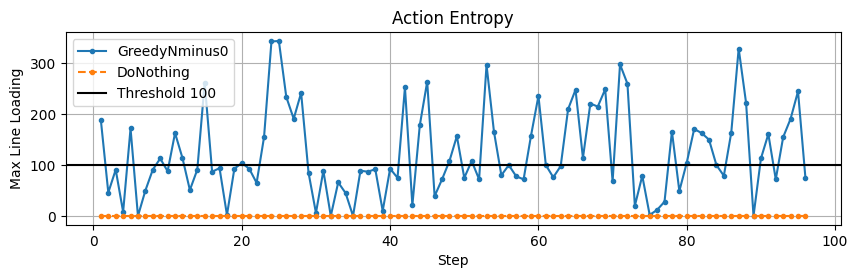

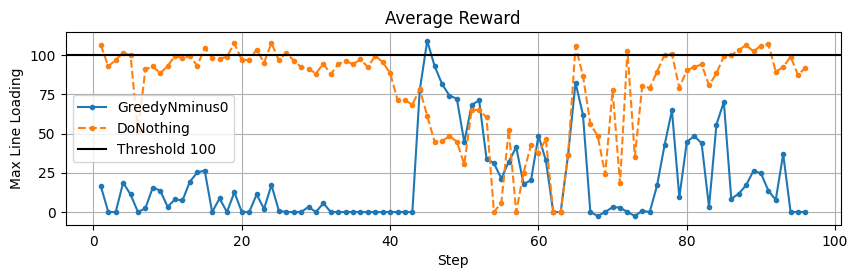

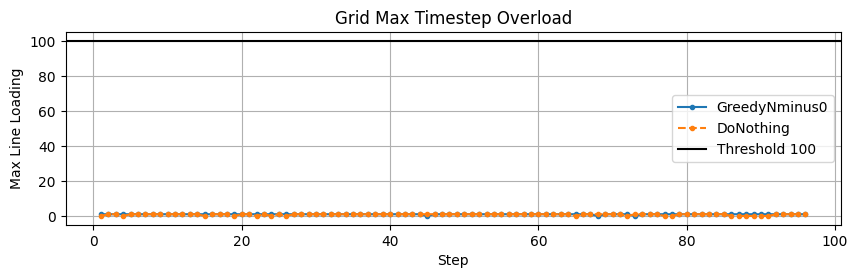

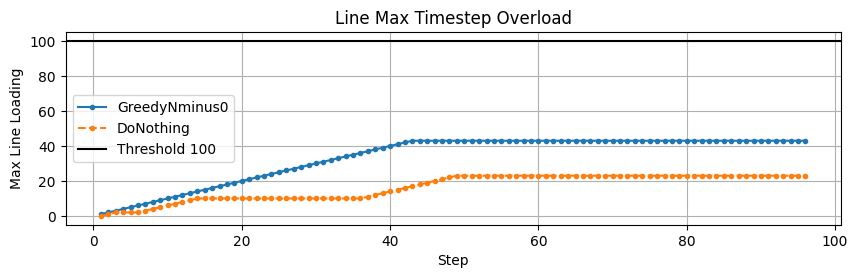

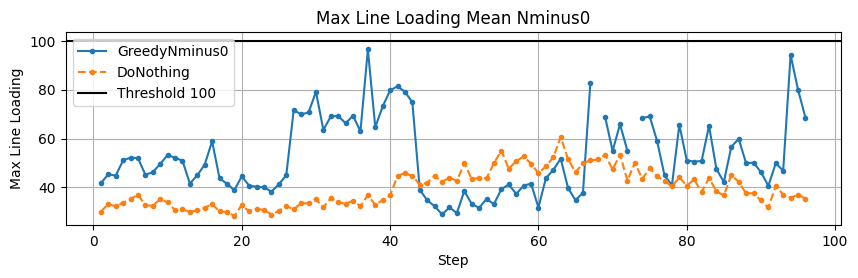

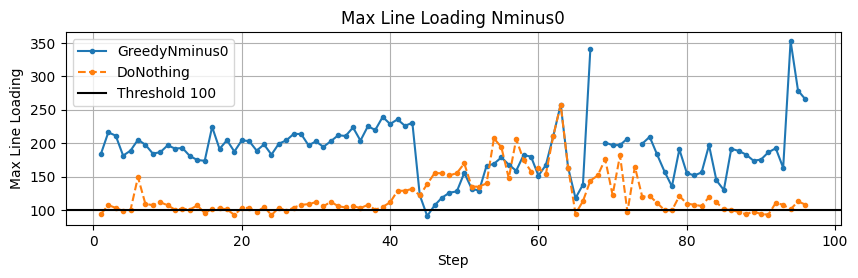

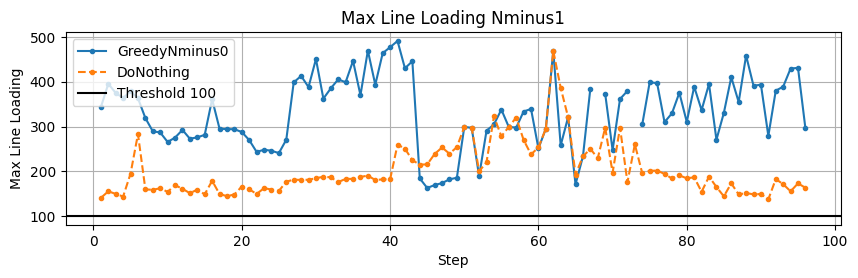

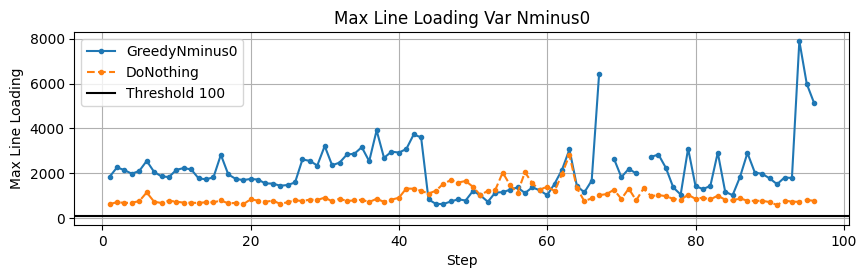

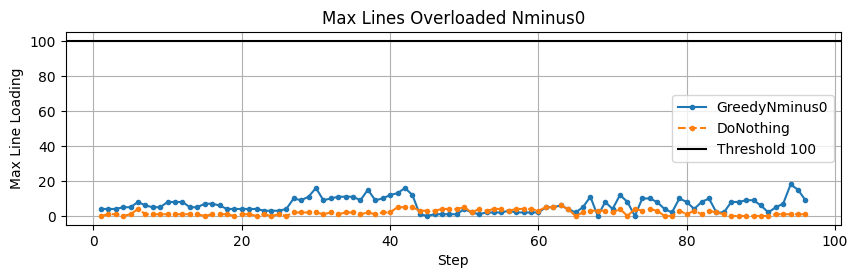

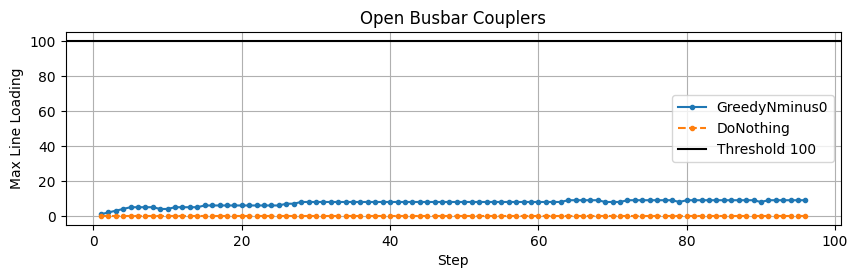

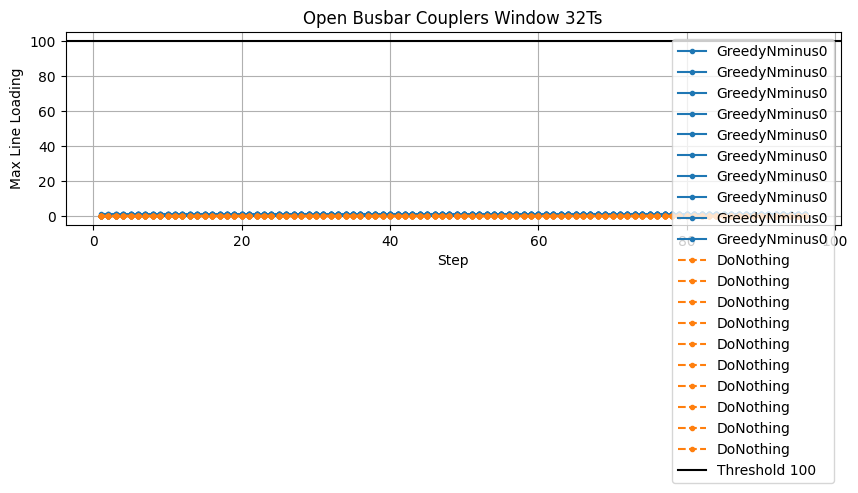

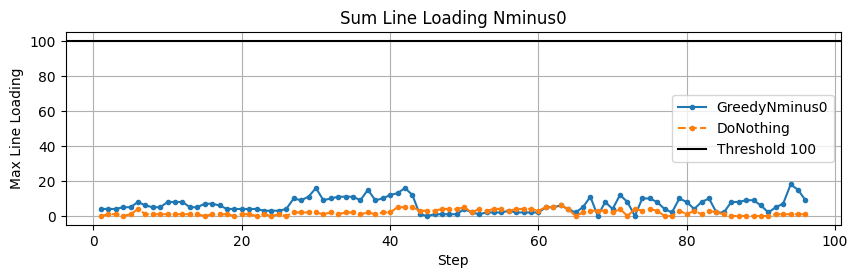

In [16]:
# plot
import matplotlib.pyplot as plt
# Save figure as PDF
import os
# Extract data

metrics = agent_results["DoNothing"].keys()
# agent_name = "GreedyNminus0"
for metric in metrics:
    # Create plot N-0
    cmap = plt.get_cmap("tab10")
    plt.figure(figsize=(10, 2.5))
    steps = range(1, 96 + 1) # 96 hardcoded
    # Set colormap and line styles
    cmap = plt.get_cmap("tab10")
    line_styles = ["-", "--", "-.", ":"]
    for idx, agent_name in enumerate(taken_actions.keys()):
        color = cmap(idx % cmap.N)
        plt.plot(
            steps,
            next(iter(agent_results[agent_name][metric]["cache"].values())),
            label=agent_name,
            linestyle=line_styles[idx % len(line_styles)],
            marker="o",
            markersize=3,
            color=color,
        )
    plt.axhline(y=100, color='black', linestyle='-', linewidth=1.5, label='Threshold 100')
    plt.xlabel('Step')
    plt.ylabel('Max Line Loading')
    plt.title(metric.replace("_", " ").title())
    plt.legend()
    plt.grid(True)



    # Create the directory if it doesn't exist
    output_dir = "plots"
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f'plots/{metric}.pdf', format='pdf')
    plt.show()

In [17]:
env.reset(options={"index": 0})
env.run_pf()


True

In [18]:
print(max(env.net.res_line["loading_percent"]))

100.80212191588002


In [19]:
# all metrics
results = eval.gather_results()
metrics = results.keys()

In [20]:
from pandapower_env.data.example_configs import config_case30
import pandapower as pp
config = config_case30()
net = config["net"]
pp.runpp(net)
print(max(net.res_line["loading_percent"]))

/Users/dkoehler/Desktop/Python Projects/Arbeit/PPTopo/pandapower_env/toolbox/utils_profiles.py:154: RuntimeWarning: divide by zero encountered in matmul
  profiles["load_p"].to_numpy() @ np.diag(net.load["scenario_scaling"]),
/Users/dkoehler/Desktop/Python Projects/Arbeit/PPTopo/pandapower_env/toolbox/utils_profiles.py:154: RuntimeWarning: overflow encountered in matmul
  profiles["load_p"].to_numpy() @ np.diag(net.load["scenario_scaling"]),
/Users/dkoehler/Desktop/Python Projects/Arbeit/PPTopo/pandapower_env/toolbox/utils_profiles.py:154: RuntimeWarning: invalid value encountered in matmul
  profiles["load_p"].to_numpy() @ np.diag(net.load["scenario_scaling"]),
/Users/dkoehler/Desktop/Python Projects/Arbeit/PPTopo/pandapower_env/toolbox/utils_profiles.py:164: RuntimeWarning: divide by zero encountered in matmul
  profiles["gen_p"].to_numpy() @ np.diag(net.gen["scenario_scaling"]),
/Users/dkoehler/Desktop/Python Projects/Arbeit/PPTopo/pandapower_env/toolbox/utils_profiles.py:164: Runti

14.019591289497201
